# 🔍 BioWord2Vec Implementation - Fine-tuning on TREC-COVID

This notebook implements our **BioWord2Vec** model with fine-tuning on the TREC-COVID dataset to improve information retrieval performance.

## Objectives
- Load the TREC-COVID dataset
- Load a Word2Vec model pre-trained on biomedical texts
- **Fine-tune the model on TREC-COVID data** (hybrid approach)
- Use general-purpose functions for search and evaluation
- Evaluate performance with NDCG@10 and compare with the pre-trained model


## 📦 1. Imports and Configuration


In [ ]:
# Required imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors, Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
from beir.datasets.data_loader import GenericDataLoader

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Import our general-purpose evaluation functions
from functions import search, top_k_ideal, evaluate_single_query, evaluate_model

print("✓ Imports completed")


✓ Imports terminés


c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\beir\datasets\data_loader.py:8: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## 📂 2. Data Loading


In [ ]:
# Path to the TREC-COVID dataset
data_path = "data/trec-covid/trec-covid"

# Check that the dataset exists
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}. Run download.py first")

print(f"Loading dataset from: {data_path}")


Chargement du dataset depuis: data/trec-covid/trec-covid


In [ ]:
# Load data with BEIR
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"✓ Corpus loaded: {len(corpus)} documents")
print(f"✓ Queries loaded: {len(queries)} queries")
print(f"✓ Qrels loaded: {len(qrels)} relevance judgments")


100%|██████████| 171332/171332 [00:01<00:00, 127925.85it/s]


✓ Corpus chargé: 171332 documents
✓ Requêtes chargées: 50 requêtes
✓ Qrels chargés: 50 jugements de pertinence


In [ ]:
# Display an example document and query
print("Example document:")
doc_id = list(corpus.keys())[0]
doc = corpus[doc_id]
print(f"ID: {doc_id}")
print(f"Title: {doc['title'][:100]}...")
print(f"Text: {doc['text'][:200]}...")

print("\nExample query:")
query_id = list(queries.keys())[0]
query = queries[query_id]
print(f"ID: {query_id}")
print(f"Text: {query}")


Exemple de document:
ID: ug7v899j
Titre: Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Ho...
Texte: OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, J...

Exemple de requête:
ID: 1
Texte: what is the origin of COVID-19


## 🔧 3. Data Preparation


### 3.1. Document Preparation and Tokenization


In [ ]:
# Prepare documents for BioWord2Vec
# We combine title and text, then tokenize
documents = []
doc_ids = []

# Load stop words
stop_words = set(stopwords.words('english'))

print("Tokenizing documents...")
for doc_id, doc in corpus.items():
    # Combine title and text
    full_text = f"{doc['title']} {doc['text']}"
    
    # Tokenize and filter stop words
    tokens = word_tokenize(full_text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    
    documents.append(tokens)
    doc_ids.append(doc_id)

print(f"✓ {len(documents)} documents prepared and tokenized")
print(f"✓ Average length: {np.mean([len(doc) for doc in documents]):.0f} words per document")


Tokenisation des documents...
✓ 171332 documents préparés et tokenisés
✓ Longueur moyenne: 94 mots par document


## 🎯 4. Loading Pre-trained BioWord2Vec Model


### 4.1. Model Download and Loading

**BioWord2Vec**:
- Word2Vec model pre-trained on biomedical texts (PubMed, PMC)
- Captures semantic relationships specific to the medical domain
- Better understanding of medical vocabulary than generic Word2Vec
- **In this notebook, we will fine-tune this model on our TREC-COVID data**


In [ ]:
import os
import urllib.request
from gensim.models import KeyedVectors

# Path configuration
model_dir = "models"
model_name = "BioWordVec_PubMed_MIMICIII_d200_sub1500000.vec.bin" # HuggingFace file name
model_path = os.path.join(model_dir, model_name)
model_url = "https://huggingface.co/ez613/BioWord2Vec_Sub1500000/resolve/main/biowordvec_sub1500000.bin"

os.makedirs(model_dir, exist_ok=True)

# 1. Check / Download
if not os.path.exists(model_path):
    print(f"⚠️ Model not found at {model_path}")
    print("Attempting download from HuggingFace...")
    try:
        # Add a User-Agent to avoid being rejected by the server
        opener = urllib.request.build_opener()
        opener.addheaders = [('User-agent', 'Mozilla/5.0')]
        urllib.request.install_opener(opener)
        
        urllib.request.urlretrieve(model_url, model_path)
        print("✓ Download successful!")
    except Exception as e:
        print(f"❌ Download error: {e}")
        print("TIP: Download the file manually and place it in the 'models/' folder.")
else:
    print(f"✅ Model found locally: {model_path}")

# 2. Load the pre-trained model
print("Loading pre-trained model into memory... (this may take 1 minute)")
try:
    # Load the model (binary=True because it's a .bin file)
    pretrained_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
    
    print("=" * 30)
    print("🚀 PRE-TRAINED BioWord2Vec LOADED")
    print(f"- Cached words: {len(pretrained_model)}")
    print(f"- Dimensions: {pretrained_model.vector_size}")
    print("=" * 30)
    
except Exception as e:
    print(f"❌ Error loading file: {e}")
    print("Check that the file is not corrupted (expected size ~1.5 GB).")


✅ Modèle trouvé localement : models\BioWordVec_PubMed_MIMICIII_d200_sub1500000.vec.bin
Chargement du modèle pré-entraîné en mémoire... (cela peut prendre 1 minute)
🚀 BioWord2Vec PRÉ-ENTRAÎNÉ CHARGÉ
- Mots en cache : 1500000
- Dimensions : 200


### 4.2. Fine-tuning the Model on TREC-COVID

**Hybrid approach**:
- Create a new Word2Vec model with the same parameters as the pre-trained model
- Initialize vectors with weights from the pre-trained model for common words
- Train the model on TREC-COVID data to adapt the representations
- This approach preserves biomedical knowledge while adapting to the specific corpus


In [ ]:
# Fine-tuning the BioWord2Vec model on TREC-COVID data
print("=" * 60)
print("🔧 FINE-TUNING BioWord2Vec MODEL")
print("=" * 60)

# 1. Create a new Word2Vec model with the same parameters
print("\n1. Creating a new Word2Vec model...")
model = Word2Vec(
    vector_size=pretrained_model.vector_size,  # 200 dimensions
    window=5,  # Standard context window
    min_count=3,  # Accept all words (even those appearing only once)
    workers=4,  # Use 4 workers for parallel training
    sg=0,  # Skip-gram (0) or CBOW (1) - use the same method as the pre-trained model
    epochs=1  # Number of iterations over the data
)

# 2. Build vocabulary with our TREC-COVID data
print("2. Building vocabulary with TREC-COVID data...")
model.build_vocab(documents)
print(f"   ✓ Vocabulary built: {len(model.wv)} words")

# 3. Initialize vectors with the pre-trained model
print("3. Initializing vectors with the pre-trained model...")
pretrained_vocab = set(pretrained_model.key_to_index.keys())
model_vocab = set(model.wv.key_to_index.keys())
common_vocab = pretrained_vocab & model_vocab

print(f"   ✓ Common words: {len(common_vocab)} / {len(model_vocab)}")
print(f"   ✓ New words in TREC-COVID: {len(model_vocab) - len(common_vocab)}")

# Copy vectors from the pre-trained model for common words
for word in common_vocab:
    model.wv[word] = pretrained_model[word]

print("   ✓ Vectors initialized with pre-trained weights")

# 4. Train the model on TREC-COVID data
print("\n4. Training the model on TREC-COVID data...")
print("   (This may take several minutes depending on corpus size)")
model.train(
    documents,
    total_examples=len(documents),
    epochs=5  # Number of iterations over the data
)

print("\n" + "=" * 60)
print("✅ FINE-TUNING COMPLETED")
print("=" * 60)
print(f"- Final vocabulary: {len(model.wv)} words")
print(f"- Dimensions: {model.wv.vector_size}")
print(f"- Words initialized from pre-training: {len(common_vocab)}")
print(f"- New words learned: {len(model_vocab) - len(common_vocab)}")
print("=" * 60)

# Save the fine-tuned model
finetuned_model_path = os.path.join(model_dir, "BioWord2Vec_finetuned_TREC-COVID.bin")
model.wv.save_word2vec_format(finetuned_model_path, binary=True)
print(f"\n💾 Fine-tuned model saved: {finetuned_model_path}")


🔧 FINE-TUNING DU MODÈLE BioWord2Vec

1. Création d'un nouveau modèle Word2Vec...
2. Construction du vocabulaire avec les données TREC-COVID...
   ✓ Vocabulaire construit: 81225 mots
3. Initialisation des vecteurs avec le modèle pré-entraîné...
   ✓ Mots communs: 69868 / 81225
   ✓ Nouveaux mots dans TREC-COVID: 11357
   ✓ Vecteurs initialisés avec les poids pré-entraînés

4. Entraînement du modèle sur les données TREC-COVID...
   (Cela peut prendre plusieurs minutes selon la taille du corpus)

✅ FINE-TUNING TERMINÉ
- Vocabulaire final: 81225 mots
- Dimensions: 200
- Mots initialisés depuis pré-entraînement: 69868
- Nouveaux mots appris: 11357

💾 Modèle fine-tuné sauvegardé: models\BioWord2Vec_finetuned_TREC-COVID.bin


### 4.3. Document Vector Creation


In [ ]:
# Function to create a document vector from word vectors
def document_to_vector(tokens, model):
    """
    Converts a document (list of tokens) into a single vector.
    Uses the mean of word vectors (simple average).
    """
    word_vectors = []
    for token in tokens:
        if token in model:
            word_vectors.append(model[token])
    
    if len(word_vectors) == 0:
        # If no words are in the vocabulary, return a zero vector
        return np.zeros(model.vector_size)
    
    # Return the mean of word vectors
    return np.mean(word_vectors, axis=0)

# Create vectors for all documents with the fine-tuned model
print("Creating document vectors with the fine-tuned model...")
doc_vectors = []

for i, tokens in enumerate(documents):
    if (i + 1) % 10000 == 0:
        print(f"  Processing document {i+1}/{len(documents)}...")
    doc_vector = document_to_vector(tokens, model.wv)
    doc_vectors.append(doc_vector)

# Convert to numpy array
doc_vectors = np.array(doc_vectors)

print(f"\n✓ Document vectors created")
print(f"  - Matrix shape: {doc_vectors.shape}")
print(f"  - Vector dimension: {doc_vectors.shape[1]}")


Création des vecteurs de documents avec le modèle fine-tuné...
  Traitement document 10000/171332...
  Traitement document 20000/171332...
  Traitement document 30000/171332...
  Traitement document 40000/171332...
  Traitement document 50000/171332...
  Traitement document 60000/171332...
  Traitement document 70000/171332...
  Traitement document 80000/171332...
  Traitement document 90000/171332...
  Traitement document 100000/171332...
  Traitement document 110000/171332...
  Traitement document 120000/171332...
  Traitement document 130000/171332...
  Traitement document 140000/171332...
  Traitement document 150000/171332...
  Traitement document 160000/171332...
  Traitement document 170000/171332...

✓ Vecteurs de documents créés
  - Forme de la matrice: (171332, 200)
  - Dimension des vecteurs: 200


### 4.4. Creating a Vectorizer Compatible with `search()`


In [ ]:
# Create a BioWord2Vec vectorizer class compatible with the search() function
class BioWord2VecVectorizer:
    """
    BioWord2Vec vectorizer compatible with the search() function from functions.py
    """
    def __init__(self, model):
        self.model = model
        self.stop_words = set(stopwords.words('english'))
    
    def transform(self, texts):
        """
        Transforms a list of texts into vectors.
        Args:
            texts: List of strings
        Returns:
            Numpy array of shape (n_texts, vector_size)
        """
        vectors = []
        for text in texts:
            tokens = word_tokenize(text.lower())
            tokens = [token for token in tokens if token.isalpha() and token not in self.stop_words]
            doc_vector = document_to_vector(tokens, self.model)
            vectors.append(doc_vector)
        return np.array(vectors)

# Create the vectorizer with the fine-tuned model
vectorizer = BioWord2VecVectorizer(model.wv)

print("✓ BioWord2Vec (fine-tuned) vectorizer created")


✓ Vectorizer BioWord2Vec (fine-tuné) créé


## 🔍 5. Relevant Document Search


### 5.1. Search Test on a Query

We use the general-purpose `search()` function from `functions.py` which works with any vectorizer.


In [ ]:
# Test the search() function on the first query
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

print(f"Test query: {test_query_id}")
print(f"Text: {test_query_text}\n")

# Use the general-purpose search() function
results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

print("Top 10 documents found:")
for i, (doc_id, score) in enumerate(results, 1):
    doc = corpus[doc_id]
    print(f"{i}. Doc {doc_id} (score: {score:.4f})")
    print(f"   Title: {doc['title'][:80]}...")
    print()


Requête test: 1
Texte: what is the origin of COVID-19

Top 10 documents trouvés:
1. Doc jkejiuf2 (score: 0.7718)
   Titre: Coronaviruses: origin and evolution...

2. Doc beguhous (score: 0.7398)
   Titre: The proximal origin of SARS-CoV-2...

3. Doc v9f5jck9 (score: 0.6696)
   Titre: Early evolution and the origin of eukaryotes...

4. Doc a7w6lael (score: 0.6666)
   Titre: Origin of SARS remains a mystery...

5. Doc ze73ajsk (score: 0.6629)
   Titre: Commentary: Origin and evolution of pathogenic coronaviruses...

6. Doc dv9m19yk (score: 0.6446)
   Titre: [What is the origin of SARS-CoV-2?]...

7. Doc 4ilpph77 (score: 0.6280)
   Titre: Probable Pangolin Origin of SARS-CoV-2 Associated with the COVID-19 Outbreak...

8. Doc h8ahn8fw (score: 0.6197)
   Titre: Origin and Evolution of the 2019 Novel Coronavirus...

9. Doc pl48ev5o (score: 0.6197)
   Titre: Origin and evolution of the 2019 novel coronavirus...

10. Doc 6foz003n (score: 0.5890)
   Titre: Diversity of Coronaviruses in Bats: In

### 5.2. Comparison with Ideal Top 10

Let's compare the model results with the ideal top 10 based on Qrels.


In [ ]:
# Compare model results with the ideal top 10
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

# Get model results
model_results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

# Get ideal top 10
ideal_results = top_k_ideal(
    query_id=test_query_id,
    qrels=qrels,
    top_k=10
)

print("=" * 80)
print(f"COMPARISON FOR QUERY {test_query_id}")
print(f"Text: {test_query_text}")
print("=" * 80)

print("\n📊 TOP 10 RETURNED BY BioWord2Vec (Fine-tuned) MODEL:")
print("-" * 80)
for i, (doc_id, biow2v_score) in enumerate(model_results, 1):
    relevance = qrels.get(test_query_id, {}).get(doc_id, 0)
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | BioWord2Vec Score: {biow2v_score:.4f} | Actual Relevance: {relevance}")
    print(f"    Title: {doc['title'][:70]}...")

print("\n✅ IDEAL TOP 10 (according to Qrels):")
print("-" * 80)
for i, (doc_id, relevance_score) in enumerate(ideal_results, 1):
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Relevance Score: {relevance_score}")
    print(f"    Title: {doc['title'][:70]}...")

# Calculate NDCG@10 score for this query with evaluate_single_query
ndcg_score = evaluate_single_query(
    query_id=test_query_id,
    model_results=model_results,
    qrels=qrels,
    k=10
)
print(f"\n📈 NDCG@10 score for this query: {ndcg_score:.4f}")


COMPARAISON POUR LA REQUÊTE 1
Texte: what is the origin of COVID-19

📊 TOP 10 RETOURNÉ PAR LE MODÈLE BioWord2Vec (Fine-tuné):
--------------------------------------------------------------------------------
 1. Doc jkejiuf2 | Score BioWord2Vec: 0.7718 | Pertinence réelle: 2
    Titre: Coronaviruses: origin and evolution...
 2. Doc beguhous | Score BioWord2Vec: 0.7398 | Pertinence réelle: 2
    Titre: The proximal origin of SARS-CoV-2...
 3. Doc v9f5jck9 | Score BioWord2Vec: 0.6696 | Pertinence réelle: 0
    Titre: Early evolution and the origin of eukaryotes...
 4. Doc a7w6lael | Score BioWord2Vec: 0.6666 | Pertinence réelle: 0
    Titre: Origin of SARS remains a mystery...
 5. Doc ze73ajsk | Score BioWord2Vec: 0.6629 | Pertinence réelle: 1
    Titre: Commentary: Origin and evolution of pathogenic coronaviruses...
 6. Doc dv9m19yk | Score BioWord2Vec: 0.6446 | Pertinence réelle: 1
    Titre: [What is the origin of SARS-CoV-2?]...
 7. Doc 4ilpph77 | Score BioWord2Vec: 0.6280 | Pertinenc

### 5.3. Search on All Queries


In [ ]:
# Search for relevant documents for all queries
print("Searching on all queries...")
print(f"(Processing {len(queries)} queries)\n")

# Dictionary to store all results: {query_id: [(doc_id, score), ...]}
all_model_results = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Processing query {i}/{len(queries)}...")
    
    # Search for top 10 documents with the general-purpose function
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors,
        doc_ids=doc_ids,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results[query_id] = results

print(f"\n✓ Search completed for all queries")


Recherche sur toutes les requêtes...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes


## 📊 6. Evaluation with NDCG@10


In [ ]:
# Evaluate the model on all queries with evaluate_model
evaluation_results = evaluate_model(
    queries=queries,
    all_model_results=all_model_results,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.6259
Min NDCG@10: 0.0000
Max NDCG@10: 1.0000
Std NDCG@10: 0.3263
Number of queries: 50


### 6.1. Score Distribution


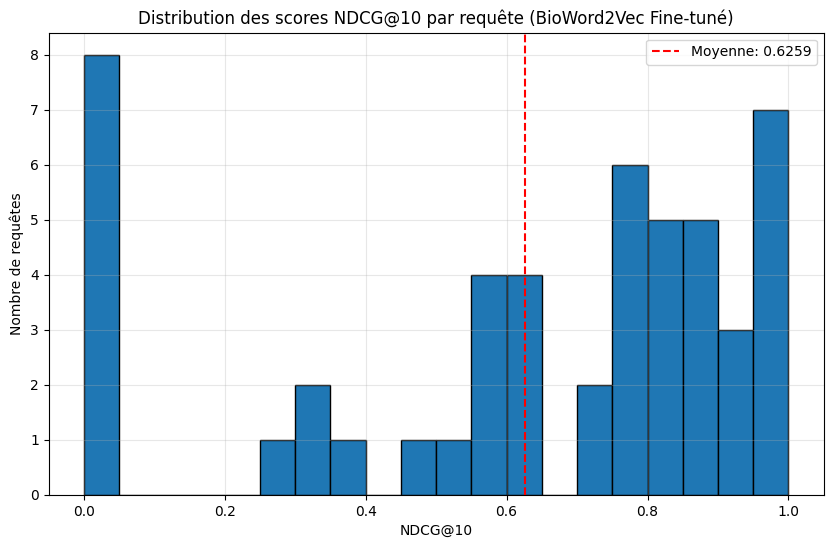

In [ ]:
# Display the distribution of NDCG@10 scores
ndcg_scores = evaluation_results['scores']

plt.figure(figsize=(10, 6))
plt.hist(list(ndcg_scores.values()), bins=20, edgecolor='black')
plt.xlabel('NDCG@10')
plt.ylabel('Number of queries')
plt.title('Distribution of NDCG@10 scores per query (BioWord2Vec Fine-tuned)')
plt.axvline(evaluation_results['mean_score'], color='r', linestyle='--', 
            label=f'Mean: {evaluation_results["mean_score"]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📈 7. Results Analysis


In [ ]:
# Display best and worst queries
ndcg_df = pd.DataFrame([
    {'query_id': qid, 'ndcg@10': score} 
    for qid, score in ndcg_scores.items()
]).sort_values('ndcg@10', ascending=False)

print("Top 5 best queries:")
print(ndcg_df.head())
print("\nTop 5 worst queries:")
print(ndcg_df.tail())


Top 5 meilleures requêtes:
   query_id   ndcg@10
38       39  1.000000
37       38  0.985789
18       19  0.967584
26       27  0.960529
20       21  0.959399

Top 5 pires requêtes:
   query_id  ndcg@10
1         2      0.0
33       34      0.0
31       32      0.0
22       23      0.0
49       50      0.0


In [ ]:
# Analyze a query with a good score
best_query_id = ndcg_df.iloc[0]['query_id']
best_query_text = queries[best_query_id]
best_ndcg = ndcg_df.iloc[0]['ndcg@10']

print(f"\nQuery with best NDCG@10 ({best_ndcg:.4f}):")
print(f"ID: {best_query_id}")
print(f"Text: {best_query_text}\n")

# Get model results for this query from all_model_results
model_results = all_model_results[best_query_id]

print("Top 5 documents returned:")
for i, (doc_id, score) in enumerate(model_results[:5], 1):
    doc = corpus[doc_id]
    relevance = qrels.get(best_query_id, {}).get(doc_id, 0)
    print(f"{i}. Doc {doc_id} (BioWord2Vec score: {score:.4f}, actual relevance: {relevance})")
    print(f"   Title: {doc['title'][:80]}...")
    print()



Requête avec le meilleur NDCG@10 (1.0000):
ID: 39
Texte: What is the mechanism of cytokine storm syndrome on the COVID-19?

Top 5 documents retournés:
1. Doc m6kxxio1 (score BioWord2Vec: 0.8607, pertinence réelle: 2)
   Titre: Cytokine storm syndrome in severe COVID-19...

2. Doc 9408n63a (score BioWord2Vec: 0.8235, pertinence réelle: 2)
   Titre: Preventing cytokine storm syndrome in COVID-19 using α-1 adrenergic receptor ant...

3. Doc pdn4x9ss (score BioWord2Vec: 0.8181, pertinence réelle: 2)
   Titre: Cytokine release syndrome in severe COVID-19...

4. Doc a1y0enrg (score BioWord2Vec: 0.8138, pertinence réelle: 2)
   Titre: mTORC inhibitor Sirolimus deprograms monocytes in “cytokine storm” in SARS-CoV2 ...

5. Doc 5c9f4m2f (score BioWord2Vec: 0.8058, pertinence réelle: 2)
   Titre: Tocilizumab: A Therapeutic Option for the Treatment of Cytokine Storm Syndrome i...



## 💾 8. Results Saving


In [ ]:
# Save results for comparison with the pre-trained model
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Save NDCG scores
ndcg_scores = evaluation_results['scores']
with open(f"{results_dir}/bioword2vec_finetuned_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores, f, indent=2)

# Save summary
summary = {
    "model": "BioWord2Vec_Fine-tuned",
    "mean_ndcg@10": evaluation_results['mean_score'],
    "min_ndcg@10": evaluation_results['min_score'],
    "max_ndcg@10": evaluation_results['max_score'],
    "std_ndcg@10": evaluation_results['std_score'],
    "num_queries": evaluation_results['num_queries'],
    "num_documents": len(doc_ids),
    "training_epochs": 5,
    "common_vocab_size": len(common_vocab),
    "new_vocab_size": len(model_vocab) - len(common_vocab)
}

with open(f"{results_dir}/bioword2vec_finetuned_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Results saved in {results_dir}/")
print(f"  - bioword2vec_finetuned_ndcg_scores.json")
print(f"  - bioword2vec_finetuned_summary.json")


✓ Résultats sauvegardés dans results/
  - bioword2vec_finetuned_ndcg_scores.json
  - bioword2vec_finetuned_summary.json
